<a href="https://colab.research.google.com/github/fatma-hesham2/HEMAYA/blob/main/Goggles__Detection_NoteBook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q ultralytics roboflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 285.0/285.0 kB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 89.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 142.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 6.6 MB/s eta 0:00:00


In [2]:
import os
import random
import yaml
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from ultralytics import YOLO
from roboflow import Roboflow

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
import torch

print("PyTorch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")

PyTorch Version: 2.11.0+cu128
CUDA Available: True
GPU Name: Tesla T4


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
PROJECT_DIR = "/content/drive/MyDrive/HEMAYA"

os.makedirs(PROJECT_DIR, exist_ok=True)

print(PROJECT_DIR)

/content/drive/MyDrive/HEMAYA


In [6]:
rf = Roboflow(api_key="0r8oTeltSdKVo6XJhMNR")
project = rf.workspace("fatma-hesham").project("safety-goggles-lipnh")
version = project.version(1)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Safety-Goggles-1 in yolov8:: 100%|██████████| 2582/2582 [00:00<00:00, 12994.73it/s]


In [7]:
path=dataset.location

In [8]:
print(os.listdir(path))

['test', 'README.roboflow.txt', 'train', 'export', 'data.yaml', 'valid', 'README.dataset.txt']


In [16]:
yaml_path = os.path.join(path, "data.yaml")
with open(yaml_path, "r") as f:
    data = yaml.safe_load(f)

data

{'names': ['eyes_with_goggles', 'eyes_without_goggles'],
 'nc': 2,
 'roboflow': {'license': 'CC BY 4.0',
  'project': 'safety-goggles-lipnh',
  'url': 'https://universe.roboflow.com/fatma-hesham/safety-goggles-lipnh/dataset/1',
  'version': 1,
  'workspace': 'fatma-hesham'},
 'test': '../test/images',
 'train': '../train/images',
 'val': '../valid/images'}

In [10]:
from glob import glob
import os

label_folders = [
    os.path.join(path, "train", "labels"),
    os.path.join(path, "valid", "labels"),
    os.path.join(path, "test", "labels")
]

for folder in label_folders:

    for file in glob(os.path.join(folder, "*.txt")):

        new_lines = []

        with open(file, "r") as f:
            lines = f.readlines()

        for line in lines:

            cls = int(line.split()[0])

            if cls in [0, 1]:
                new_lines.append(line)

        with open(file, "w") as f:
            f.writelines(new_lines)

print("Done")

Done


In [15]:
from glob import glob
import os

label_folders = [
    os.path.join(path, "train", "labels"),
    os.path.join(path, "valid", "labels"),
    os.path.join(path, "test", "labels")
]

empty_files = 0
non_empty_files = 0

for folder in label_folders:

    label_files = glob(os.path.join(folder, "*.txt"))

    for file in label_files:

        with open(file, "r") as f:
            lines = f.readlines()

        if len(lines) == 0:
            empty_files += 1
        else:
            non_empty_files += 1

print("="*40)
print("Empty Label Files     :", empty_files)
print("Non-Empty Label Files :", non_empty_files)
print("Total Label Files     :", empty_files + non_empty_files)
print("="*40)

Empty Label Files     : 15
Non-Empty Label Files : 1272
Total Label Files     : 1287


In [11]:
import yaml

yaml_path = os.path.join(path, "data.yaml")

with open(yaml_path, "r") as f:
    data = yaml.safe_load(f)

data["nc"] = 2

data["names"] = [
    "eyes_with_goggles",
    "eyes_without_goggles"
]

with open(yaml_path, "w") as f:
    yaml.dump(data, f)

print(data)

{'names': ['eyes_with_goggles', 'eyes_without_goggles'], 'nc': 2, 'roboflow': {'license': 'CC BY 4.0', 'project': 'safety-goggles-lipnh', 'url': 'https://universe.roboflow.com/fatma-hesham/safety-goggles-lipnh/dataset/1', 'version': 1, 'workspace': 'fatma-hesham'}, 'test': '../test/images', 'train': '../train/images', 'val': '../valid/images'}


In [18]:
from glob import glob
import os

train_images = glob(os.path.join(path, "train", "images", "*"))
valid_images = glob(os.path.join(path, "valid", "images", "*"))
test_images = glob(os.path.join(path, "test", "images", "*"))

print(f"Train Images      : {len(train_images)}")
print(f"Validation Images : {len(valid_images)}")
print(f"Test Images       : {len(test_images)}")

print("-" * 35)

print(f"Total Images      : {len(train_images) + len(valid_images) + len(test_images)}")

Train Images      : 901
Validation Images : 258
Test Images       : 128
-----------------------------------
Total Images      : 1287


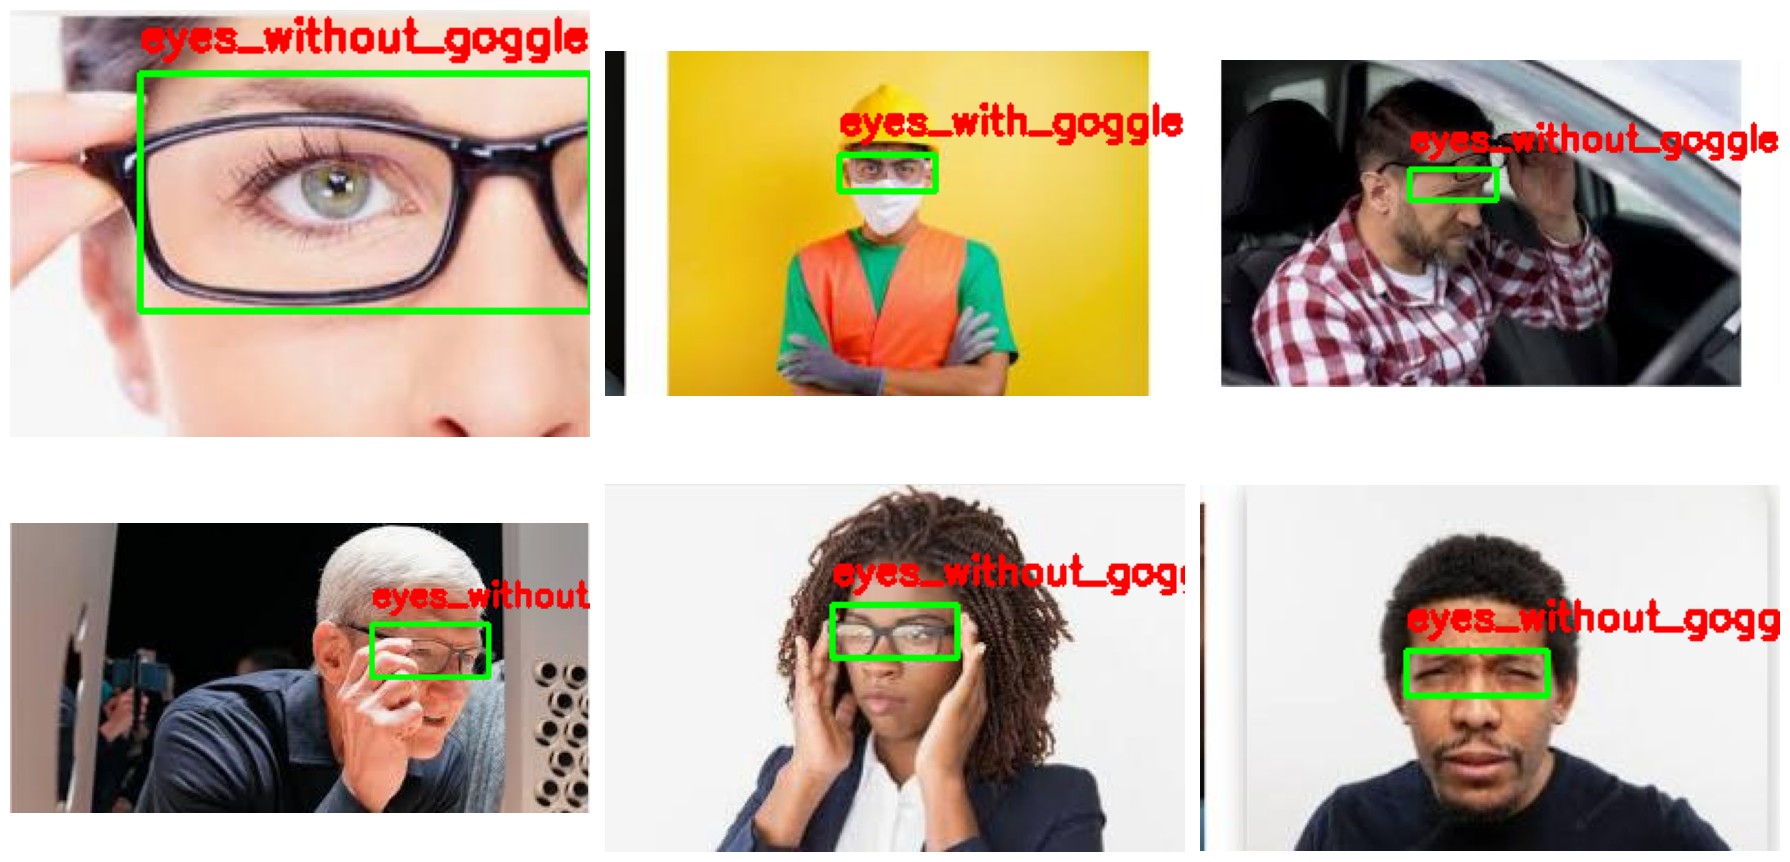

In [19]:
sample_images = random.sample(train_images, 6)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for ax, img_path in zip(axes, sample_images):


    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    h, w = img.shape[:2]

    label_path = img_path.replace("images", "labels")
    label_path = os.path.splitext(label_path)[0] + ".txt"

    if os.path.exists(label_path):

        with open(label_path, "r") as f:

            for line in f.readlines():

                cls, x_center, y_center, bw, bh = map(float, line.split())


                x_center *= w
                y_center *= h
                bw *= w
                bh *= h

                x1 = int(x_center - bw / 2)
                y1 = int(y_center - bh / 2)
                x2 = int(x_center + bw / 2)
                y2 = int(y_center + bh / 2)

                cv2.rectangle(img, (x1, y1), (x2, y2), (0,255,0), 2)

                cv2.putText(
                    img,
                    data["names"][int(cls)],
                    (x1, y1-10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.6,
                    (255,0,0),
                    2
                )

    ax.imshow(img)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [20]:
model = YOLO("yolo26n.pt")

In [21]:
results = model.train(
    data= yaml_path,

    epochs=50,
    imgsz=640,
    batch=16,

    device=0,

    project=PROJECT_DIR,
    name="Goggles_YOLO26N",

    optimizer="SGD",
    lr0=0.01,
    momentum=0.937,
    weight_decay=0.0005,

    pretrained=True,

    workers=2,
    patience=20,

    save=True,
    plots=True,
    val=True,

    seed=42
)

Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Safety-Goggles-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=Goggles_YOLO26N-2, nbs=64

In [22]:
print(results.save_dir)

/content/drive/MyDrive/HEMAYA/Goggles_YOLO26N-2


In [23]:
best_model = YOLO(os.path.join(results.save_dir, "weights", "best.pt"))

metrics = best_model.val()

Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,375,226 parameters, 0 gradients, 5.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 259.9±85.3 MB/s, size: 6.1 KB)
val: Scanning /content/Safety-Goggles-1/valid/labels.cache... 258 images, 3 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 258/258 77.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 17/17 4.2it/s 4.0s
                   all        258        298      0.808      0.771      0.824       0.44
     eyes_with_goggles         73         74      0.749      0.725      0.786      0.442
  eyes_without_goggles        186        224      0.868      0.817      0.862      0.438
Speed: 1.9ms preprocess, 8.8ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to /content/runs/detect/val



image 1/1 /content/Safety-Goggles-1/test/images/no-glasses-631-_png.rf.cbd8a905c9626135d71aafa7ae958c34.jpg: 640x640 1 eyes_without_goggles, 15.9ms
Speed: 4.3ms preprocess, 15.9ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict


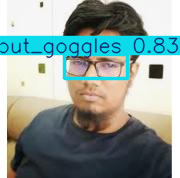

In [27]:
results = best_model.predict(
    source=test_images[0],
    conf=0.5,
    save=True
)

results[0].show()

In [26]:
model = YOLO("yolo26n.pt")

results = model.train(
    data=yaml_path,

    epochs=50,
    imgsz=640,
    batch=16,

    device=0,

    project=PROJECT_DIR,
    name="Goggles_YOLO26N_Aug",

    optimizer="SGD",
    lr0=0.01,
    momentum=0.937,
    weight_decay=0.0005,

    pretrained=True,

    # Augmentation
    hsv_h=0.015,
    hsv_s=0.5,
    hsv_v=0.3,

    degrees=3,
    translate=0.05,
    scale=0.2,

    fliplr=0.5,

    mosaic=0.3,
    mixup=0.0,

    workers=2,
    patience=20,

    save=True,
    plots=True,
    val=True,

    seed=42
)

Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Safety-Goggles-1/data.yaml, degrees=3, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.5, hsv_v=0.3, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=0.3, multi_scale=0.0, name=Goggles_YOLO26N_Aug, nbs=64

In [29]:
print(os.path.join(PROJECT_DIR, "Goggles_YOLO26N_Aug"))

/content/drive/MyDrive/HEMAYA/Goggles_YOLO26N_Aug


In [31]:
best_model_path = os.path.join(PROJECT_DIR, "Goggles_YOLO26N_Aug", "weights", "best.pt")
best_model = YOLO(best_model_path)

metrics = best_model.val()

Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,375,226 parameters, 0 gradients, 5.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 302.5±84.1 MB/s, size: 6.8 KB)
val: Scanning /content/Safety-Goggles-1/valid/labels.cache... 258 images, 3 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 258/258 72.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 17/17 4.9it/s 3.5s
                   all        258        298      0.797      0.738      0.794      0.413
     eyes_with_goggles         73         74      0.686       0.73      0.753        0.4
  eyes_without_goggles        186        224      0.908      0.747      0.836      0.427
Speed: 1.9ms preprocess, 3.8ms inference, 0.0ms loss, 0.2ms postprocess per image
Results saved to /content/runs/detect/val-2



image 1/1 /content/Safety-Goggles-1/test/images/no-glasses-631-_png.rf.cbd8a905c9626135d71aafa7ae958c34.jpg: 640x640 1 eyes_without_goggles, 8.9ms
Speed: 2.7ms preprocess, 8.9ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict-2


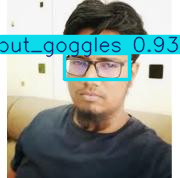

In [32]:
results = best_model.predict(
    source=test_images[0],
    conf=0.5,
    save=True
)

results[0].show()